In [1]:
!pip install git+https://github.com/k329272/kestrel -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install roboflow -q
from roboflow import Roboflow
from google.colab import userdata
rf = Roboflow(api_key=userdata.get("RoboflowAPIKey"))
project = rf.workspace(userdata.get("RoboflowWorkspace")).project(userdata.get("RoboflowProject"))
version = project.version(9)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.6 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to rock-paper-scissors-9 in yolov8:: 100%|██████████| 29057/29057 [00:02<00:00, 13219.26it/s]


In [3]:
import kestrel
import yaml
from pathlib import Path

# Path to the data.yaml file
data_yaml_path = Path("./rock-paper-scissors-9/data.yaml")

# Load the data.yaml content
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Update paths if they are in the problematic format
for split_key in ['train', 'val', 'test']:
    if split_key in data_config and isinstance(data_config[split_key], str) and data_config[split_key].startswith('../'):
        data_config[split_key] = data_config[split_key][3:]

# Save the updated data.yaml content
with open(data_yaml_path, 'w') as f:
    yaml.safe_dump(data_config, f)

model = kestrel("kestrel26n.yaml")
print(model.train(data=data_yaml_path, epochs=3))

train:   0%|          | 0/3 [00:00<?, ?epoch/s]

batch:   0%|          | 0/242 [00:00<?, ?batch/s]

batch:   0%|          | 0/242 [00:00<?, ?batch/s]

batch:   0%|          | 0/242 [00:00<?, ?batch/s]

{'class_loss': 1.1045367967643414, 'bbox_loss': 0.014352496069652838, 'class_accuracy': 0.4192634560906516, 'total_loss': 1.1188892928339942}


predict:   0%|          | 0/1 [00:00<?, ?image/s]

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 45,  57,  85],
        [ 45,  57,  85],
        [ 44,  56,  84],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 44,  56,  84],
        [ 44,  56,  84],
        [ 43,  55,  83],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 43,  55,  83],
        [ 43,  55,  83],
        [ 42,  54,  82],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
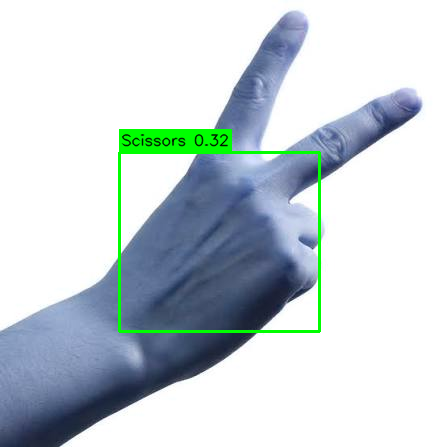

In [4]:
model.val()
results = model("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSHjNGIYkWtyGK8Ps366rtNj0g9HDontzqzcpY_Z5KYLQ&s=10")
results[0].plot()

In [5]:
model.save("kestrel26n.pt")
model.export(format="torchscript", path="kestrel_model.torchscript.pt")

'kestrel_model.torchscript.pt'

In [6]:
from google.colab import files, runtime
files.download("kestrel_model.torchscript.pt")
runtime.unassign()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>